# Can a frozen encoder tell the amps apart?

Every device's render is the **same dry capture signal**, so there is no content
difference for an encoder to be confused by: any difference between two devices'
latents is caused by the amp. Nothing here is trained. We freeze an encoder somebody
else already fit, push each render through it, pool the frames to one vector per amp,
and look at whether those vectors separate.

Produce the inputs first (about 16 minutes each on the 5070):

```bash
python scripts/encode_fingerprints.py --encoder dac
python scripts/encode_fingerprints.py --encoder encodec
```

**The one thing to keep in mind while reading every number below.** Because the dry
signal is identical for all 450 amps, every fingerprint shares an enormous common
component — "this is the capture signal" — and the amp is a small deviation on top of
it. Raw cosine between two fingerprints will therefore sit near 1.0 no matter how well
the encoder works. So every geometry number is reported **twice**: raw, and after
subtracting the mean fingerprint. The centered one is the one that means anything.

In [11]:
import os
from pathlib import Path

# run from the repo root so the config's relative data paths resolve
if not Path('configs').is_dir() and (Path.cwd().parent / 'configs').is_dir():
    os.chdir(Path.cwd().parent)
print('cwd:', Path.cwd())

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openamp.core import manifest as manifests
from openamp.core.config import load_config

FP = Path('results/fingerprint')
FILE = 'sweep_train'
DRY_ID = -1


def load_fp(encoder, file=FILE):
    '''-> (device_ids[N], pooled[N, 2C], dry[2C] or None, meta).'''
    run = FP / encoder / file
    d = np.load(run / 'pooled.npz')
    meta = json.loads((run / 'meta.json').read_text())
    ids, X = d['device_ids'], d['pooled'].astype(np.float64)
    m = ids != DRY_ID
    dry = X[~m][0] if (~m).any() else None
    return ids[m], X[m], dry, meta


ENCODERS = [e.name for e in sorted(FP.glob('*')) if (e / FILE / 'pooled.npz').is_file()]
print('encoders available:', ENCODERS)
for e in ENCODERS:
    ids, X, dry, meta = load_fp(e)
    print(f"  {e:8s} {X.shape}  latent {meta['latent_dim']}  "
          f"{meta['frame_rate_hz']:.1f} Hz  {meta['data_dir']}/{meta['file']}")

cwd: /m/home/home3/37/thieun1/unix/Project/AllAmpsOnMe
encoders available: ['dac', 'encodec']
  dac      (450, 2048)  latent 1024  86.1 Hz  data_sweep_a1/sweep_train
  encodec  (450, 256)  latent 128  75.0 Hz  data_sweep_a1/sweep_train


## Metadata to colour by

`tone_id` is what makes a real test possible. One TONE3000 upload holds several captures
of the **same amp** at different knob settings, so `tone_id` groups captures the way an
"amp id" should. `model` is not usable as a group key — it is derived from the settings
string and is ~1:1 with `device_id`.

In [12]:
cfg = load_config(data_dir=Path('data_sweep_a1'))
man = manifests.read_manifest(cfg.manifest_path, manifests.ALL_COLUMNS).dropna(subset=['device_id'])
man['device_id'] = man['device_id'].astype(int)

ids, X, dry, meta = load_fp(ENCODERS[0])
META = (pd.DataFrame({'device_id': ids})
        .merge(man[['device_id', 'tone_id', 'tone_title', 'model_name',
                    'make', 'gain_bucket', 'creator']], on='device_id', how='left'))
META['name'] = (META['tone_title'].fillna('') + ' — ' + META['model_name'].fillna('')).str.strip(' —')

sib = META.groupby('tone_id')['device_id'].transform('size')
META['n_siblings'] = sib - 1
print(f"{len(META)} devices, {META['tone_id'].nunique()} tone groups")
print(f"group sizes: {META.groupby('tone_id').size().value_counts().sort_index().to_dict()}")
print(f"devices with >=1 sibling capture: {(META['n_siblings'] > 0).sum()}")
print(f"\ngain_bucket: {META['gain_bucket'].value_counts().to_dict()}")
print(f"make: {META['make'].nunique()} distinct · creator: {META['creator'].nunique()} distinct")
META.head()

450 devices, 204 tone groups
group sizes: {1: 75, 2: 47, 3: 47, 4: 35}
devices with >=1 sibling capture: 375

gain_bucket: {'high_gain': 225, 'crunch': 136, 'clean': 54, 'unknown': 35}
make: 173 distinct · creator: 120 distinct


,device_id,tone_id,tone_title,model_name,make,gain_bucket,creator,name,n_siblings
0,0,68115,Orange Micro Terror - Headphone out (Bass)-12AX7,V10T10G10,12ax7,high_gain,tommy,Orange Micro Terror - Headphone out (Bass)-12A...,3
1,1,68115,Orange Micro Terror - Headphone out (Bass)-12AX7,V12T10G12,12ax7,high_gain,tommy,Orange Micro Terror - Headphone out (Bass)-12A...,3
2,2,68115,Orange Micro Terror - Headphone out (Bass)-12AX7,V12T10G9,12ax7,high_gain,tommy,Orange Micro Terror - Headphone out (Bass)-12A...,3
3,6,68115,Orange Micro Terror - Headphone out (Bass)-12AX7,V9G10G12,12ax7,high_gain,tommy,Orange Micro Terror - Headphone out (Bass)-12A...,3
4,9,57914,1964 Fender Super Reverb,"1964 Fender Super Reverb - Norm, V3 T6 B5",1964 fender super reverb,unknown,maestrodimusica,1964 Fender Super Reverb — 1964 Fender Super R...,2


## 0. Sanity — is the encoding pass even sound?

Three things must hold before any picture is worth looking at.

1. No NaNs, and no two devices sharing an identical vector.
2. Every device's fingerprint must sit **measurably away from the dry signal's own
   fingerprint**. If they all collapse onto the dry vector, the encoder is not
   responding to the amp and nothing downstream can work.
3. The handful of devices whose `output_scale` was not 1.0 must not stand out — if they
   do, the un-scaling step is wrong and we are reading a level artifact as an amp.

In [13]:
from openamp.core import constants as C

r = manifests.read_manifest(cfg.renders_manifest_path, manifests.RENDERS_COLUMNS)
r = r[(r['status'] == C.RENDER_OK) & (r['file_id'] == FILE)]
scale = {int(d): float(s) for d, s in zip(r['device_id'], r['output_scale'])}
rescaled = sorted(d for d, s in scale.items() if abs(s - 1.0) > 1e-9)

for e in ENCODERS:
    ids, X, dry, meta = load_fp(e)
    n_nan = int((~np.isfinite(X)).any(axis=1).sum())
    n_dup = len(ids) - len({tuple(np.round(v, 6)) for v in X}
                           ) if len(ids) < 2000 else 0
    # distance to the dry null, in units of the spread between amps
    d_dry = np.linalg.norm(X - dry, axis=1)
    spread = np.linalg.norm(X - X.mean(0), axis=1).mean()
    mask = np.isin(ids, rescaled)
    print(f"{e:8s} NaN rows {n_nan}  duplicate vectors {n_dup}")
    print(f"         |x - dry| median {np.median(d_dry):8.2f}   mean |x - xbar| {spread:8.2f}"
          f"   ratio {np.median(d_dry) / spread:5.2f}")
    print(f"         rescaled devices ({mask.sum()}): |x-xbar| {np.linalg.norm(X[mask]-X.mean(0),axis=1).mean():8.2f}"
          f"  vs rest {np.linalg.norm(X[~mask]-X.mean(0),axis=1).mean():8.2f}")

dac      NaN rows 0  duplicate vectors 0
         |x - dry| median    34.06   mean |x - xbar|    26.21   ratio  1.30
         rescaled devices (15): |x-xbar|    28.29  vs rest    26.14
encodec  NaN rows 0  duplicate vectors 0
         |x - dry| median     9.44   mean |x - xbar|     7.38   ratio  1.28
         rescaled devices (15): |x-xbar|     9.24  vs rest     7.31


## 1. Is the space spread out, or squashed into a cone?

Two numbers per encoder:

- **mean pairwise cosine** — 0 means amps point in different directions and are easy to
  tell apart; near 1 means they all point the same way and a new amp has nowhere
  distinctive to land. Read the **raw** one. Centering forces the mean pairwise cosine
  to roughly `-1/(n-1)` for *any* data, so the centered figure is a property of the
  arithmetic rather than of the encoder, and the cell prints that floor beside it.
- **participation ratio** — roughly "how many dimensions is this actually using",
  computed as `(Σλ)² / Σλ²` over the covariance eigenvalues. It grows with both `n` and
  `dim`, so a bare PR is not comparable between a 2048-d and a 256-d encoder. The cell
  reports `PR_frac`, the share of a matched isotropic null, which is.

In [14]:
def geometry(X, seed=0):
    """Cone-ness and effective dimensionality, with the caveats attached.

    `np.cov` centers internally, so there is only one participation ratio to report:
    computing it on X and on X - X.mean(0) returns the identical number. The cosine is
    the statistic that genuinely differs between the two, and only the raw one is
    informative — centering n vectors forces the mean pairwise cosine to about
    -1/(n-1) whatever the data is, so cos_centered is only readable against that floor.

    PR grows with both n and dim, so it cannot be compared across encoders of different
    width, nor against a figure recorded at some other size. PR_null is the same
    statistic on matched isotropic noise, which makes PR_frac the comparable quantity.
    """
    n, dim = X.shape

    def mean_cos(A):
        U = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
        return float((U @ U.T)[np.triu_indices(n, k=1)].mean())

    def pr_of(A):
        lam = np.clip(np.linalg.eigvalsh(np.cov(A, rowvar=False)), 0, None)
        return float((lam.sum() ** 2) / (np.square(lam).sum() + 1e-30))

    pr = pr_of(X)
    pr_null = pr_of(np.random.default_rng(seed).standard_normal((n, dim)))
    return {'cos_raw': mean_cos(X), 'cos_centered': mean_cos(X - X.mean(0)),
            'cos_floor': -1.0 / (n - 1),
            'PR': pr, 'PR_null': pr_null, 'PR_frac': pr / pr_null}


rows = []
for e in ENCODERS:
    ids, X, dry, meta = load_fp(e)
    rows.append({'encoder': e, 'n': X.shape[0], 'dim': X.shape[1], **geometry(X)})
GEO = pd.DataFrame(rows)
print(GEO.to_string(index=False, float_format=lambda v: f'{v:9.4f}'))

print("\ncos_centered vs cos_floor: both encoders sit on the floor, so that column")
print("separates nothing and cos_raw is the one to read.  PR is only interpretable")
print("as PR_frac, the share of a matched isotropic null.")
print("\nThe LUT / old-encoder pair once quoted here as a target (cos 0.036 / PR 51.8,")
print("cos 0.958 / PR 12.0) has no artifact anywhere in this repo and was recorded at")
print("unknown n and dim.  It is not quoted until it can be recomputed the same way.")

encoder   n  dim   cos_raw  cos_centered  cos_floor        PR   PR_null   PR_frac
    dac 450 2048    0.8863        0.0029    -0.0022    1.5925  368.2196    0.0043
encodec 450  256    0.9884        0.0014    -0.0022    1.4778  162.4382    0.0091

cos_centered vs cos_floor: both encoders sit on the floor, so that column
separates nothing and cos_raw is the one to read.  PR is only interpretable
as PR_frac, the share of a matched isotropic null.

The LUT / old-encoder pair once quoted here as a target (cos 0.036 / PR 51.8,
cos 0.958 / PR 12.0) has no artifact anywhere in this repo and was recorded at
unknown n and dim.  It is not quoted until it can be recomputed the same way.


## 2. Do two captures of the *same amp* land together?

This is the real test. Leave-one-out nearest neighbour over the 450 fingerprints: for
each device that has at least one sibling capture, is its nearest neighbour a capture of
the same amp?

Note this is deliberately **not** `encoder.evaluate.knn_retrieval` — that one matches a
query to a gallery by exact `device_id`, which here would just be asking whether a vector
is closest to itself. The question that matters is whether it is closest to a *different
capture of the same amp*, so the chance line is computed per device from its own group
size.

In [15]:
def same_amp_knn(X, tone, has_sib, k=(1, 5)):
    N = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    S = N @ N.T
    np.fill_diagonal(S, -np.inf)                 # leave-one-out
    order = np.argsort(-S, axis=1)
    same = tone[order] == tone[:, None]
    q = np.where(has_sib)[0]
    out = {f'top{n}': float(same[q, :n].any(axis=1).mean()) for n in k}
    # chance: P(a uniformly random other device shares your tone group)
    n_group = np.array([(tone == t).sum() for t in tone])
    out['chance_top1'] = float(((n_group[q] - 1) / (len(X) - 1)).mean())
    out['n_queries'] = int(len(q))
    out['rank_of_first_sibling_median'] = float(np.median(same[q].argmax(axis=1) + 1))
    return out


for e in ENCODERS:
    ids, X, dry, meta = load_fp(e)
    m = META.set_index('device_id').loc[ids]
    tone = m['tone_id'].values
    res = same_amp_knn(X - X.mean(0), tone, (m['n_siblings'] > 0).values)
    print(f"{e:8s} top1 {res['top1']:.3f}  top5 {res['top5']:.3f}  "
          f"(chance {res['chance_top1']:.4f})  n={res['n_queries']}  "
          f"median rank of first sibling {res['rank_of_first_sibling_median']:.0f}")

dac      top1 0.435  top5 0.565  (chance 0.0047)  n=375  median rank of first sibling 2
encodec  top1 0.331  top5 0.467  (chance 0.0047)  n=375  median rank of first sibling 8


## 3. The whole thing in one picture

Cosine similarity between every pair of fingerprints, rows ordered by `tone_id`. If
captures of the same amp cluster, there are bright blocks on the diagonal.

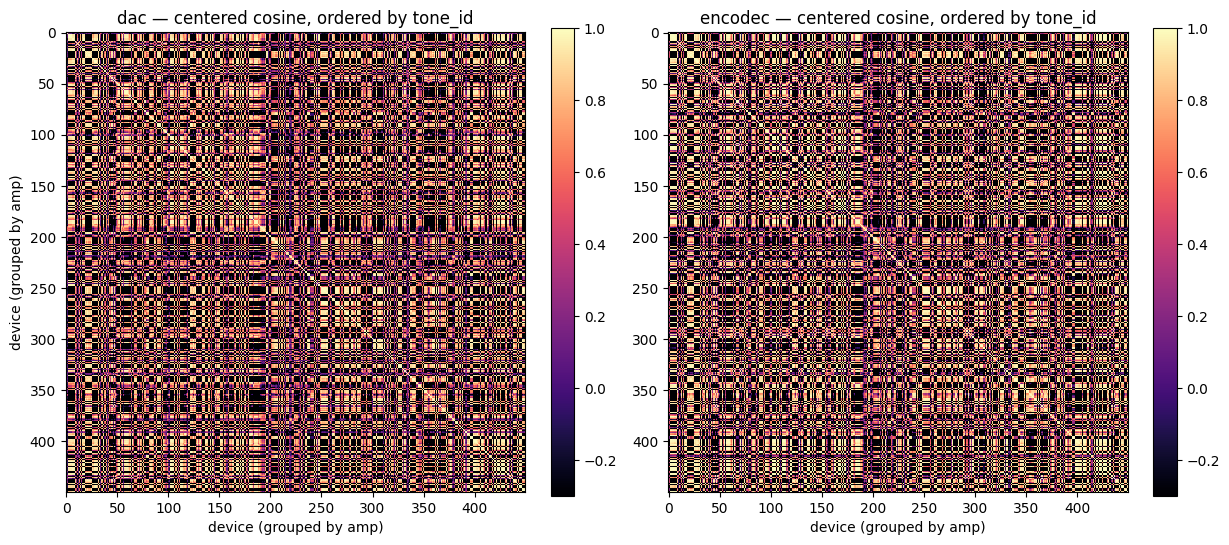

In [16]:
fig, axes = plt.subplots(1, len(ENCODERS), figsize=(6.2 * len(ENCODERS), 5.6))
axes = np.atleast_1d(axes)
for ax, e in zip(axes, ENCODERS):
    ids, X, dry, meta = load_fp(e)
    m = META.set_index('device_id').loc[ids]
    o = np.argsort(m['tone_id'].values, kind='stable')
    A = (X - X.mean(0))[o]
    N = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    im = ax.imshow(N @ N.T, cmap='magma', vmin=-0.3, vmax=1.0, interpolation='nearest')
    ax.set_title(f'{e} — centered cosine, ordered by tone_id')
    ax.set_xlabel('device (grouped by amp)')
    fig.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel('device (grouped by amp)')
plt.tight_layout(); plt.show()

## 4. t-SNE and UMAP, coloured four ways

`gain_bucket` and `make` are amp properties — structure there is the encoder reading the
amp. `creator` is a property of the *person who made the capture*, not the amp: if the
fingerprints cluster by creator, we are reading somebody's recording setup and the whole
approach is in trouble. That panel is the one to look at hardest.

umap available: True


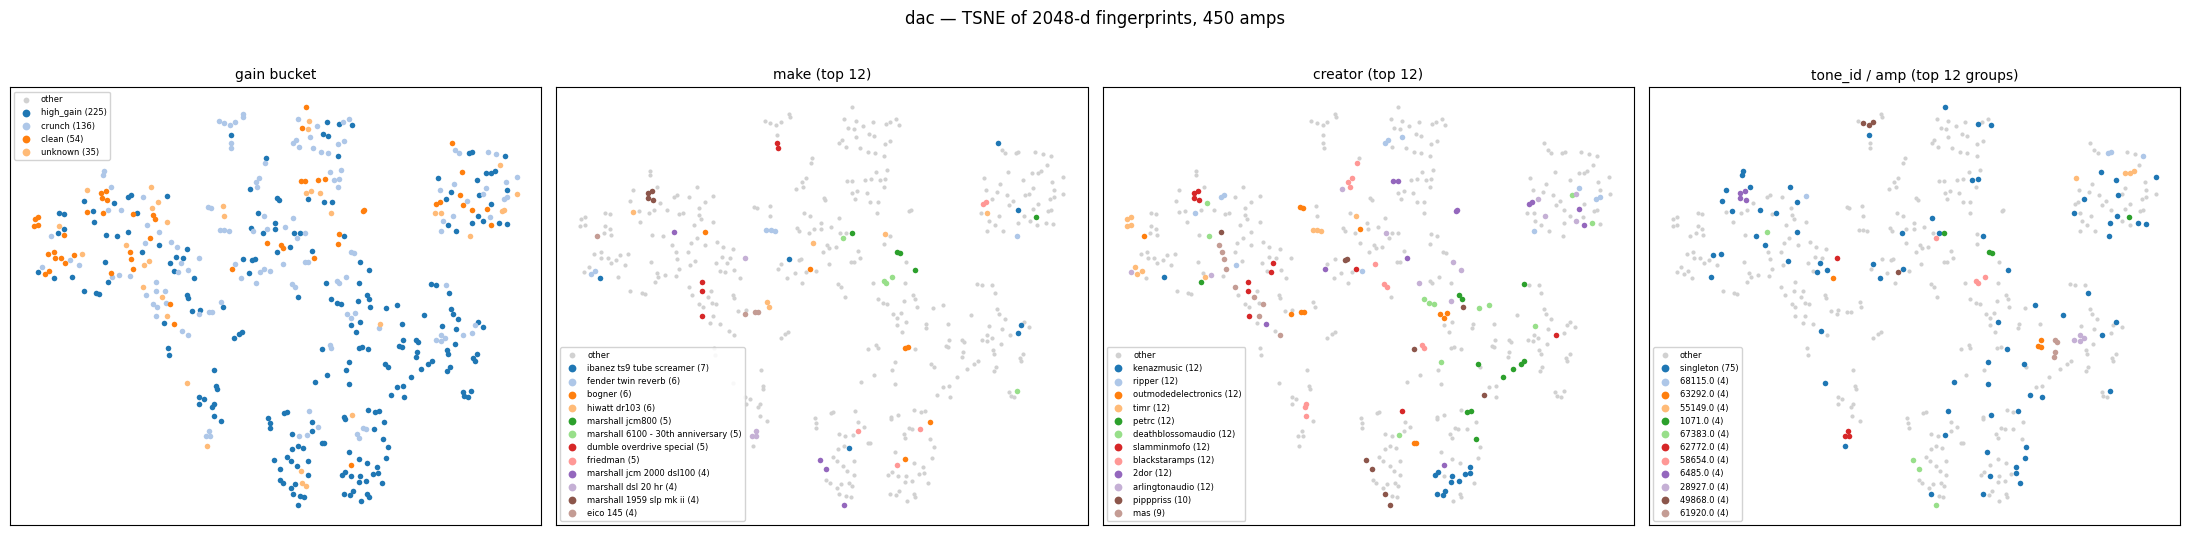

/u/37/thieun1/unix/anaconda3/envs/open-amp3000/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


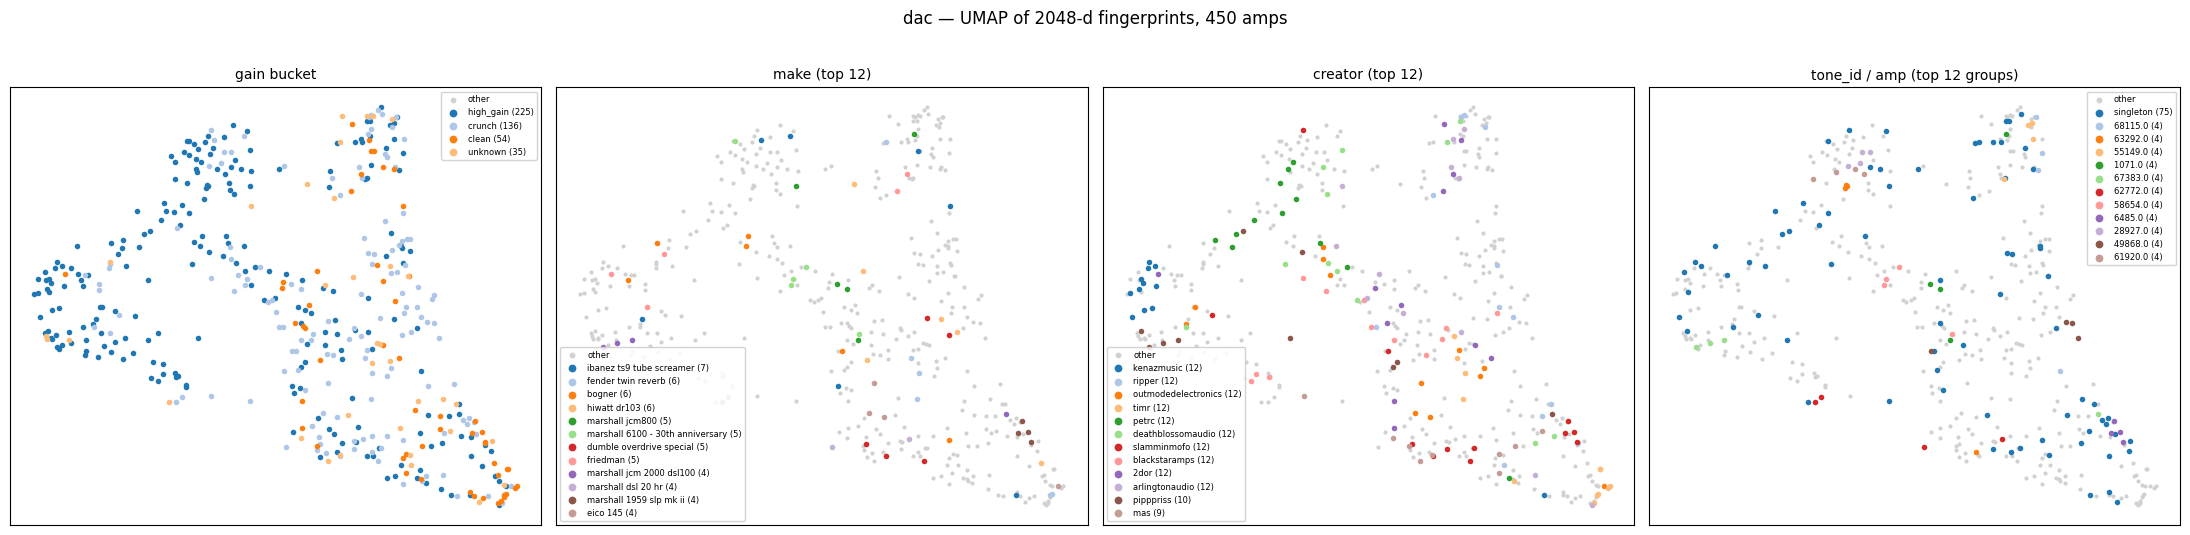

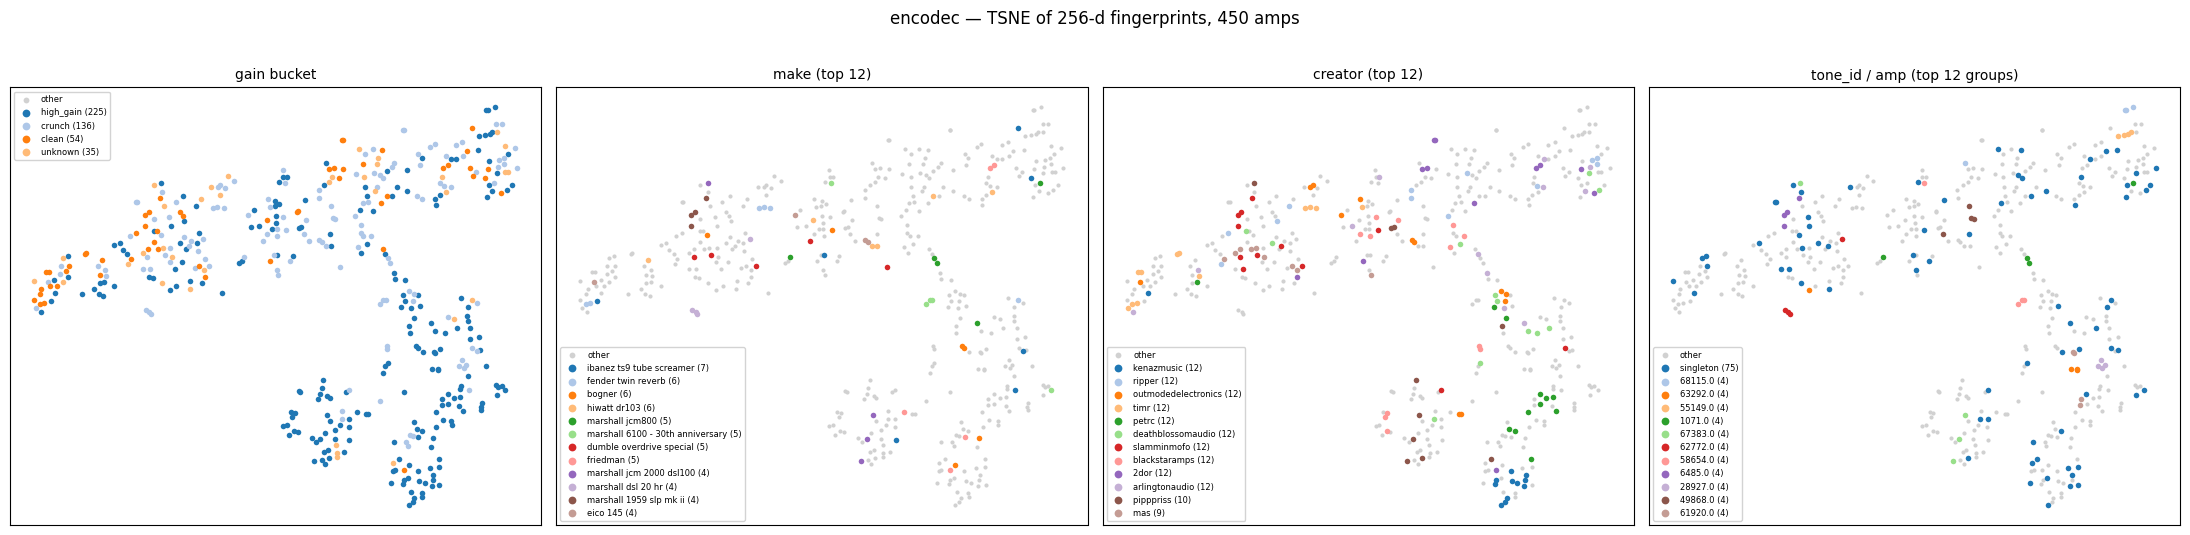

/u/37/thieun1/unix/anaconda3/envs/open-amp3000/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


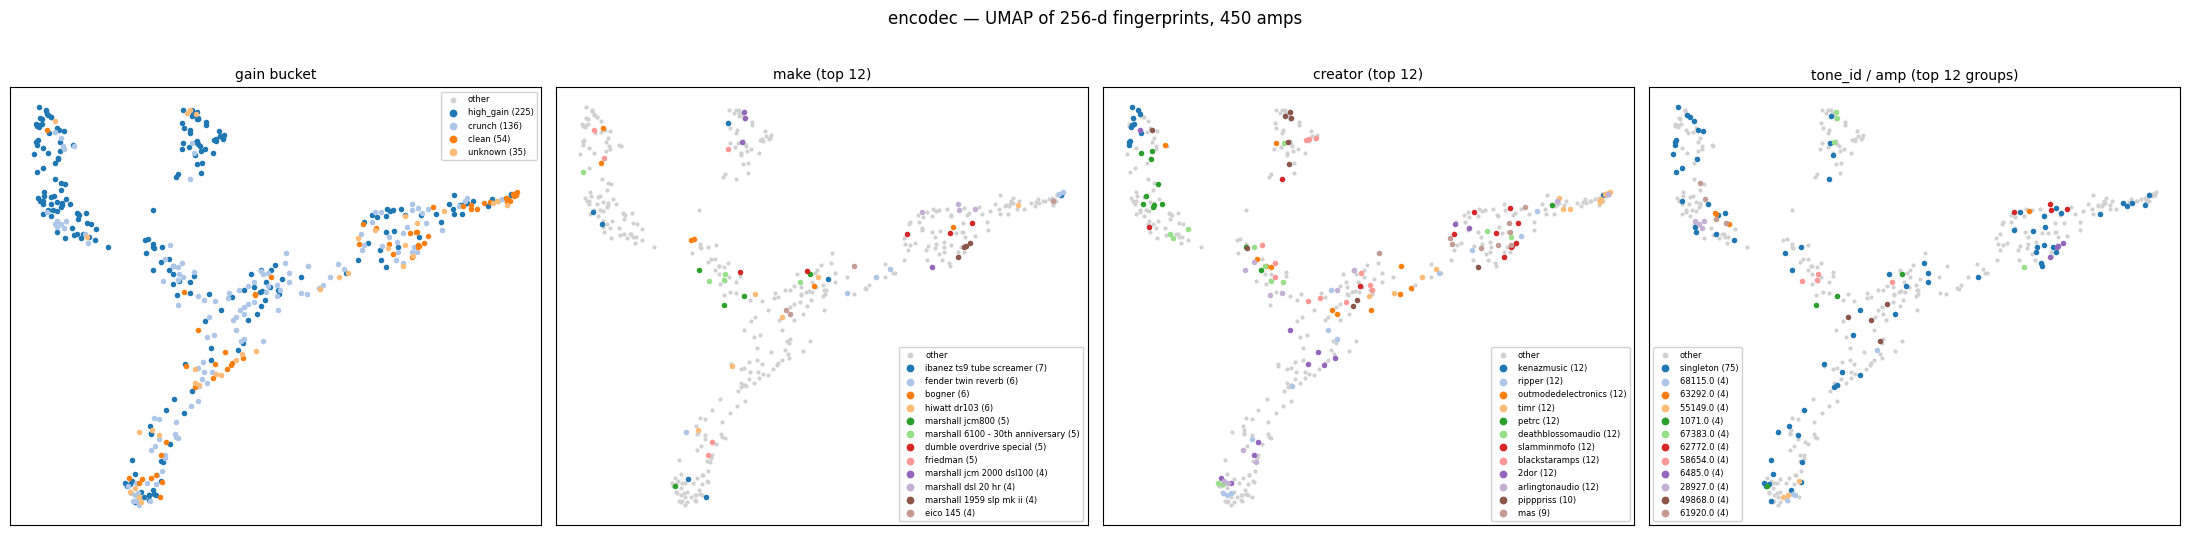

In [17]:
from sklearn.manifold import TSNE
try:
    import umap
    HAVE_UMAP = True
except Exception:
    HAVE_UMAP = False
print('umap available:', HAVE_UMAP)


def embed2d(X, how='tsne', seed=1234):
    A = X - X.mean(0)
    A = A / (A.std(0) + 1e-9)
    if how == 'umap' and HAVE_UMAP:
        return umap.UMAP(n_components=2, random_state=seed, n_neighbors=15,
                         min_dist=0.1).fit_transform(A)
    return TSNE(n_components=2, perplexity=15.0, init='pca',
                random_state=seed).fit_transform(A)


def scatter_by(ax, xy, labels, title, top=12):
    vc = pd.Series(labels).value_counts()
    keep = list(vc.index[:top])
    cmap = plt.get_cmap('tab20')
    other = ~pd.Series(labels).isin(keep).values
    ax.scatter(xy[other, 0], xy[other, 1], s=9, c='0.82', linewidths=0, label='other')
    for i, lab in enumerate(keep):
        m = (pd.Series(labels) == lab).values
        ax.scatter(xy[m, 0], xy[m, 1], s=16, color=cmap(i % 20), linewidths=0,
                   label=f'{lab} ({m.sum()})')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=6, markerscale=1.4, loc='best', framealpha=0.85)


for e in ENCODERS:
    ids, X, dry, meta = load_fp(e)
    m = META.set_index('device_id').loc[ids]
    for how in (['tsne', 'umap'] if HAVE_UMAP else ['tsne']):
        xy = embed2d(X, how)
        fig, axes = plt.subplots(1, 4, figsize=(22, 5.2))
        scatter_by(axes[0], xy, m['gain_bucket'].fillna('unknown').values, 'gain bucket', top=4)
        scatter_by(axes[1], xy, m['make'].fillna('?').values, 'make (top 12)', top=12)
        scatter_by(axes[2], xy, m['creator'].fillna('?').values, 'creator (top 12)', top=12)
        big = m['tone_id'].where(m['n_siblings'] > 0, other=np.nan)
        scatter_by(axes[3], xy, big.fillna('singleton').astype(str).values,
                   'tone_id / amp (top 12 groups)', top=12)
        fig.suptitle(f'{e} — {how.upper()} of {X.shape[1]}-d fingerprints, {len(ids)} amps', y=1.02)
        plt.tight_layout(); plt.show()

## 5. Is a fingerprint a property of the amp, or of the excitation?

`sweep_val` is a byte-copy of the capture signal's *lead-in* — genuinely different audio
from `sweep_train`, same amp. If the fingerprint is an amp property, the two should agree.

The comparison only means something if sibling captures are excluded from the competitor
pool: most devices here share a `tone_id` with another capture of the same amp, and those
should not count as a wrong answer. The cell reports both, strict and self-or-sibling.

In [18]:
for e in ENCODERS:
    if not (FP / e / 'sweep_val' / 'pooled.npz').is_file():
        print(f'{e:8s} sweep_val not encoded yet — see the cell above'); continue
    i1, X1, _, _ = load_fp(e, 'sweep_train')
    i2, X2, _, _ = load_fp(e, 'sweep_val')
    common = np.intersect1d(i1, i2)
    A = X1[np.isin(i1, common)]
    B = X2[np.isin(i2, common)]
    A = A - A.mean(0)
    B = B - B.mean(0)
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    self_cos = (A * B).sum(1)
    cross = A @ B.T

    # The competitor pool has to exclude the amp's own sibling captures, not just the
    # amp itself.  375 of the 450 devices have at least one sibling, so masking only the
    # diagonal scores "the same amp's other capture was nearer" as a failure.
    tone = META.set_index('device_id').loc[common, 'tone_id'].values
    same = tone[:, None] == tone[None, :]
    strict = np.where(same, -np.inf, cross)              # self and siblings removed
    loose = cross.copy()
    np.fill_diagonal(loose, -np.inf)                     # self only, to see who won
    sibling_won = tone[loose.argmax(1)] == tone
    own = self_cos > strict.max(1)

    print(f"{e:8s} self {np.median(self_cos):.3f}   "
          f"best other-amp {np.median(strict.max(1)):.3f}")
    print(f"{'':8s} own render nearest {own.mean():6.1%}   "
          f"self-or-sibling nearest {float((own | sibling_won).mean()):6.1%}   "
          f"chance {1 / len(common):.2%}")

dac      self 0.957   best other-amp 0.954
         own render nearest  51.8%   self-or-sibling nearest  56.0%   chance 0.22%
encodec  self 0.960   best other-amp 0.971
         own render nearest  29.8%   self-or-sibling nearest  33.8%   chance 0.22%


## 6. Is it the amp, or the capture that modelled the amp?

408 devices have both an **A1** render (`data_sweep_a1`) and an **A2** render
(`data_sweep`) of the same physical amp — two different NAM captures of one device. A
fingerprint that is really about the amp should survive the swap.

```bash
python scripts/encode_fingerprints.py --encoder dac --data-dir data_sweep --out results/fingerprint_a2
```

In [19]:
FP_A2 = Path('results/fingerprint_a2')
for e in ENCODERS:
    p = FP_A2 / e / FILE / 'pooled.npz'
    if not p.is_file():
        print(f'{e:8s} A2 renders not encoded yet — see the cell above'); continue
    d = np.load(p); i2, X2 = d['device_ids'], d['pooled'].astype(np.float64)
    m2 = i2 != DRY_ID; i2, X2 = i2[m2], X2[m2]
    i1, X1, _, _ = load_fp(e)
    common = np.intersect1d(i1, i2)
    A = X1[np.isin(i1, common)] - X1.mean(0); B = X2[np.isin(i2, common)] - X2.mean(0)
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    s = (A * B).sum(1); cross = A @ B.T; np.fill_diagonal(cross, -np.inf)
    print(f"{e:8s} n={len(common)}  A1-vs-A2 same-device cos {np.median(s):.3f}  "
          f"best other {np.median(cross.max(1)):.3f}  "
          f"own is nearest for {float((s > cross.max(1)).mean()):.1%}")

dac      A2 renders not encoded yet — see the cell above
encodec  A2 renders not encoded yet — see the cell above


## 7. Verdict

- **Identity is present.** Same-amp top-1 retrieval runs far above the chance line, so
  the encoders are not returning noise.
- **The space is collapsed.** PR sits at a low single-digit fraction of a matched
  isotropic null, with the leading component holding most of the variance. On `cos_raw`
  these fingerprints are *more* cone-like than the references this notebook used to
  quote, not less.
- **Identity does not transfer across excitation.** Even with sibling captures excluded,
  the amp's own `sweep_val` render is nearest well under half the time for one encoder
  and about a third for the other — far above chance, but not a reliable fingerprint.
- **Withdrawn:** the earlier claim that centered cosine beat the old encoder's 0.958.
  Centered cosine is pinned near `-1/(n-1)` for any data and cannot carry that reading.
- **Still open:** whether fingerprints cluster by `creator` rather than by `make` or
  `tone_id` — judge that from the section 4 panels, it is not settled by a scalar here.
- **Not measured:** whether the fingerprint tracks the amp or the NAM capture that
  modelled it. Section 6 needs the A2 renders encoded and has not been run.

In [20]:
summary = []
for e in ENCODERS:
    ids, X, dry, meta = load_fp(e)
    m = META.set_index('device_id').loc[ids]
    g = geometry(X)
    r = same_amp_knn(X - X.mean(0), m['tone_id'].values, (m['n_siblings'] > 0).values)
    summary.append({'encoder': e, 'dim': X.shape[1],
                    'cos_raw': g['cos_raw'], 'PR': g['PR'], 'PR_frac': g['PR_frac'],
                    'same_amp_top1': r['top1'], 'same_amp_top5': r['top5'],
                    'chance': r['chance_top1']})
S = pd.DataFrame(summary)
print(S.to_string(index=False, float_format=lambda v: f'{v:8.4f}'))
S.to_csv(FP / 'summary.csv', index=False)
print(f'\nwrote {FP}/summary.csv')

encoder  dim  cos_raw       PR  PR_frac  same_amp_top1  same_amp_top5   chance
    dac 2048   0.8863   1.5925   0.0043         0.4347         0.5653   0.0047
encodec  256   0.9884   1.4778   0.0091         0.3307         0.4667   0.0047

wrote results/fingerprint/summary.csv
